STEP 3 - FEATURE ENGINEERING
Feature selection and data preparation for ML model

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/valemoravale/Documents/UNIVERSIDAD /Semestre 5/ETL/workshop3/data/processed/happiness_clean_unified_2015_2019.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   year      country  happiness_rank  happiness_score      gdp  \
0  2015  Switzerland               1            7.587  1.39651   
1  2015      Iceland               2            7.561  1.30232   
2  2015      Denmark               3            7.527  1.32548   
3  2015       Norway               4            7.522  1.45900   
4  2015       Canada               5            7.427  1.32629   

   social_support   health  freedom  generosity  corruption  
0         1.34951  0.94143  0.66557     0.29678     0.41978  
1         1.40223  0.94784  0.62877     0.43630     0.14145  
2         1.36058  0.87464  0.64938     0.34139     0.48357  
3         1.33095  0.88521  0.66973     0.34699     0.36503  
4         1.32261  0.90563  0.63297     0.45811     0.32957  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             781 non-null

In [5]:
features = [
    "year",
    "gdp",
    "health",
    "social_support",
    "freedom",
    "corruption",
    "generosity"
]

target = "happiness_score"

df_model = df[features + [target]].copy()

Se seleccionaron esas variables para el features debido a que son numericas y son las que influyen en el resultado del happiness_score que va a ser el target se excluyo happiness_rank para evitar target leakage debido a que este representa el orden en el que quedaron en la lista por año asi que es una prueba muy directa para el modelo porque esta directamente relacionado con el puntaje de felicidad. 

In [6]:
print("Descriptive statistics")
print(df_model.describe())

Descriptive statistics
              year         gdp      health  social_support     freedom  \
count   781.000000  781.000000  781.000000      781.000000  781.000000   
mean   2016.992318    0.914537    0.612342        1.078780    0.411254   
std       1.417814    0.405403    0.248459        0.329581    0.152911   
min    2015.000000    0.000000    0.000000        0.000000    0.000000   
25%    2016.000000    0.605000    0.440060        0.870210    0.310480   
50%    2017.000000    0.982000    0.647240        1.125000    0.431000   
75%    2018.000000    1.233750    0.808000        1.328000    0.531000   
max    2019.000000    1.870770    1.141000        1.644000    0.724000   

       corruption  generosity  happiness_score  
count  781.000000  781.000000       781.000000  
mean     0.125436    0.218618         5.377232  
std      0.105816    0.122394         1.127071  
min      0.000000    0.000000         2.693000  
25%      0.054000    0.130000         4.509000  
50%      0.09100

In [8]:
correlation = df_model.corr(numeric_only=True)

print("Correlation with happiness_score")
print(correlation["happiness_score"].sort_values(ascending=False))

Correlation with happiness_score
happiness_score    1.000000
gdp                0.789719
health             0.742843
social_support     0.651246
freedom            0.553365
corruption         0.398417
generosity         0.138142
year               0.005946
Name: happiness_score, dtype: float64


Mediante la correlacion se puede ver que las variables mas correlacionadas con happiness_score son gdp, health, social_support, freedom y corruption y las que menos encuentran una correlacion son generosity y year

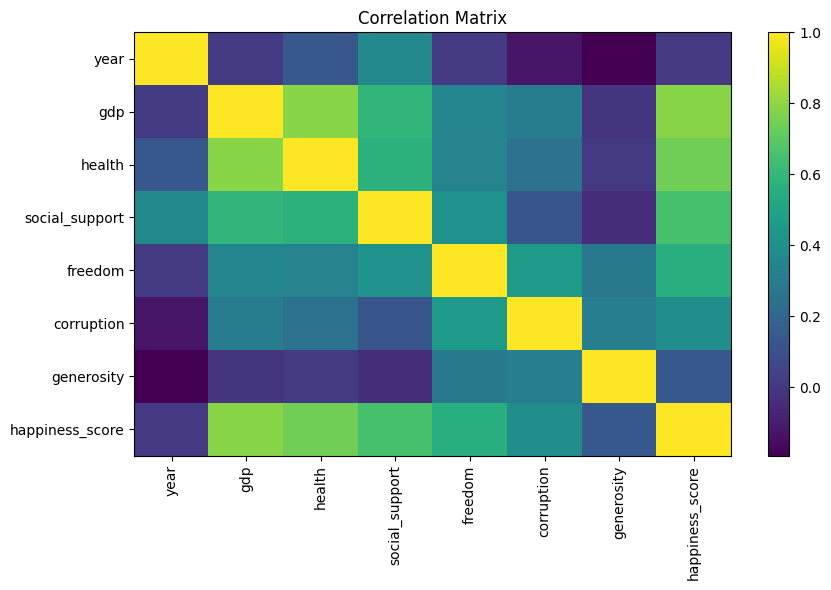

In [9]:
plt.figure(figsize=(9, 6))
plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

con la matriz de correlacion se puede evidenciar los resultados anteriores donde los que poseen colores mas azulados son los que tienen menos correlacion con happiness_score pero tambien permite evidenciar la correlacion entre diferentes variables

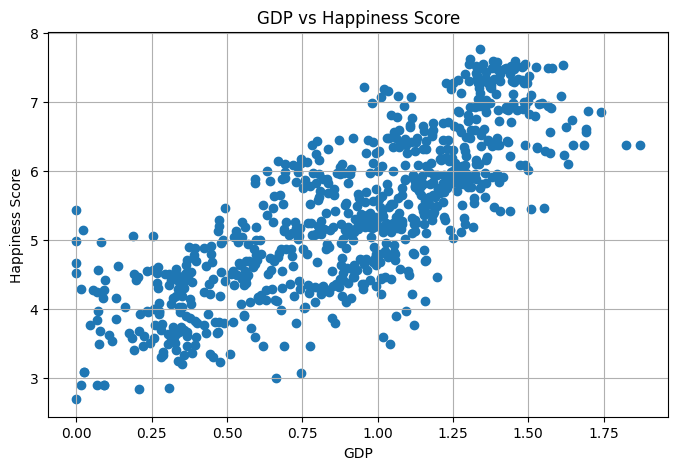

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["gdp"], df_model["happiness_score"])
plt.xlabel("GDP")
plt.ylabel("Happiness Score")
plt.title("GDP vs Happiness Score")
plt.grid(True)
plt.show()

Se observa una relación positiva entre gdp y happiness_score, lo que indica que los países con mayor aporte económico tienden a presentar mayores puntajes de felicidad.

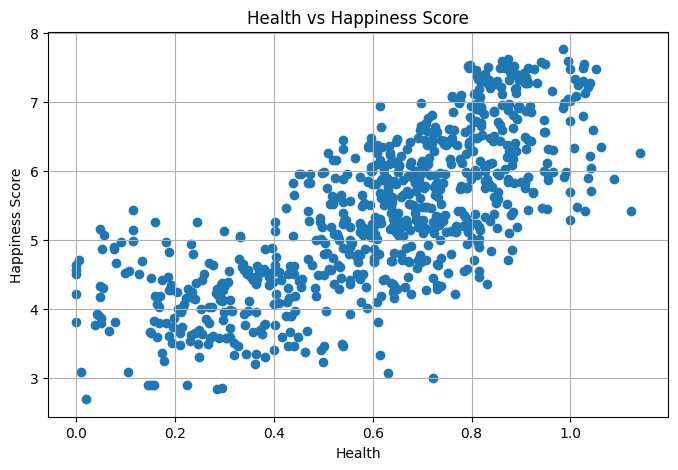

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["health"], df_model["happiness_score"])
plt.xlabel("Health")
plt.ylabel("Happiness Score")
plt.title("Health vs Happiness Score")
plt.grid(True)
plt.show()

Se observa una relación positiva entre health y happiness_score, lo que indica que los países con mayor esperanza de vida tienden a presentar mayores puntajes de felicidad.

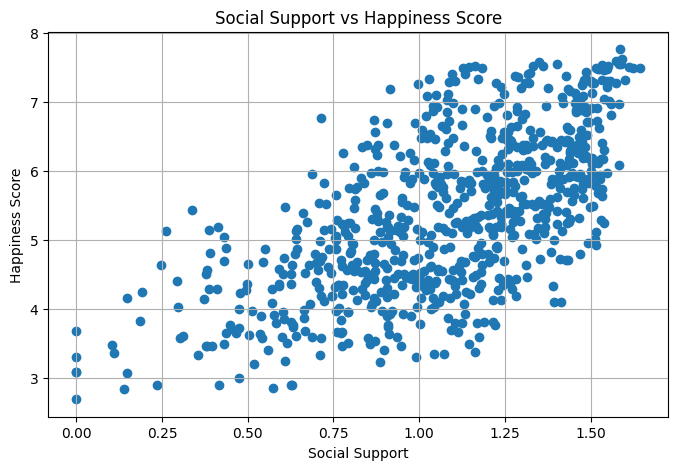

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["social_support"], df_model["happiness_score"])
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")
plt.title("Social Support vs Happiness Score")
plt.grid(True)
plt.show()

Se observa una relación positiva entre social_support y happiness_score, lo que indica que los países con mayor soporte social tienden a presentar mayores puntajes de felicidad.

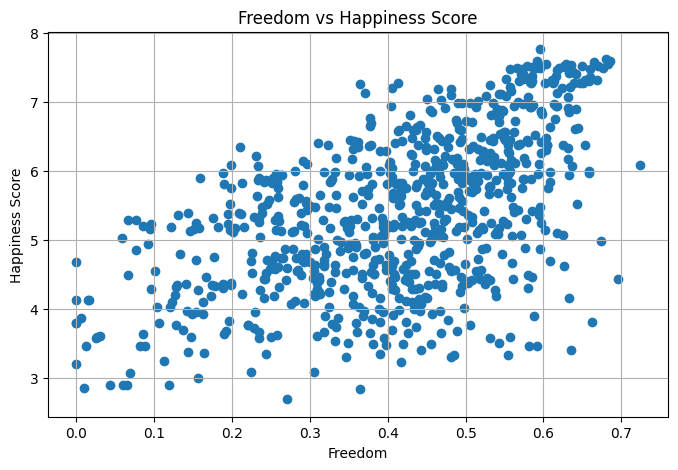

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["freedom"], df_model["happiness_score"])
plt.xlabel("Freedom")
plt.ylabel("Happiness Score")
plt.title("Freedom vs Happiness Score")
plt.grid(True)
plt.show()

Se observa una relación positiva moderada entre freedom y happiness_score, aunque los datos presentan dispersión, los países con mayores valores de libertad tienden a registrar mayores puntajes de felicidad.

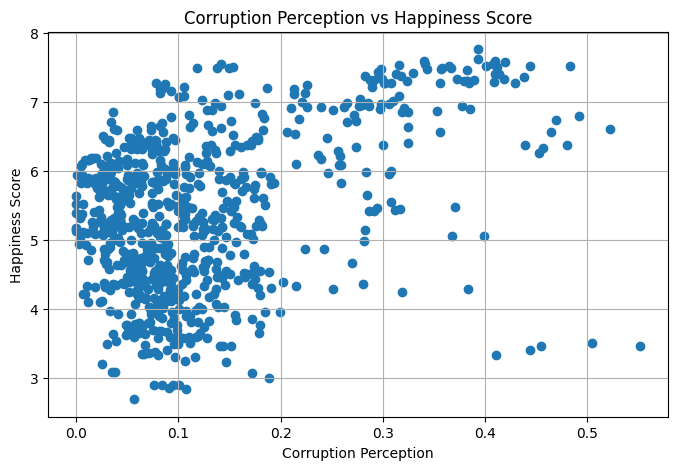

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["corruption"], df_model["happiness_score"])
plt.xlabel("Corruption Perception")
plt.ylabel("Happiness Score")
plt.title("Corruption Perception vs Happiness Score")
plt.grid(True)
plt.show()

La variable corruption representa un indicador asociado a la percepción de corrupción o confianza institucional. En este dataset, valores más altos se interpretan como una mejor percepción institucional, no como mayor corrupción.

Se observa una relación positiva debil a moderada entre corruption_perception y happiness_score, Los datos se encuentran bastante dispersos, especialmente en valores bajos del indicador, por lo que la relación no es tan fuerte visualmente. Sin embargo, la correlación muestra que esta variable sí aporta información al modelo, aunque con menor fuerza que otras variables.


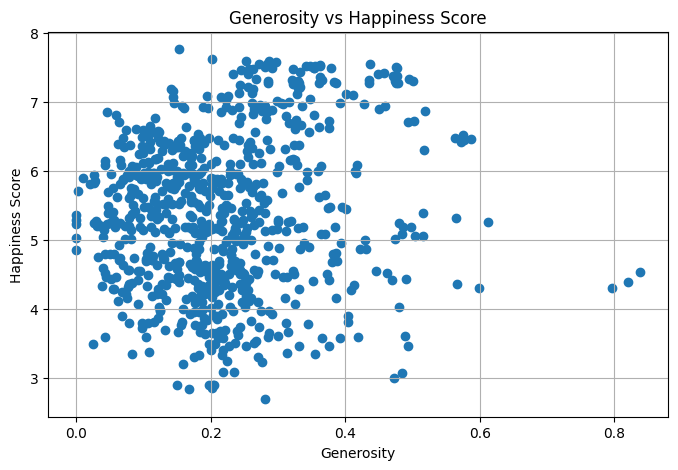

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df_model["generosity"], df_model["happiness_score"])
plt.xlabel("Generosity")
plt.ylabel("Happiness Score")
plt.title("Generosity vs Happiness Score")
plt.grid(True)
plt.show()

Se observa una relación positiva baja a moderada entre generosity y happiness_score, aunque los datos presentan dispersión, tendiendo mas a valores bajos de generosity para score altos, los países con mayores valores de generosidad tienden a registrar mayores puntajes de felicidad pero la relacion no es muy alta a comparacion con las otras relaciones pero tampoco nula por ende hay que tenerla en cuenta.

<Figure size 800x500 with 0 Axes>

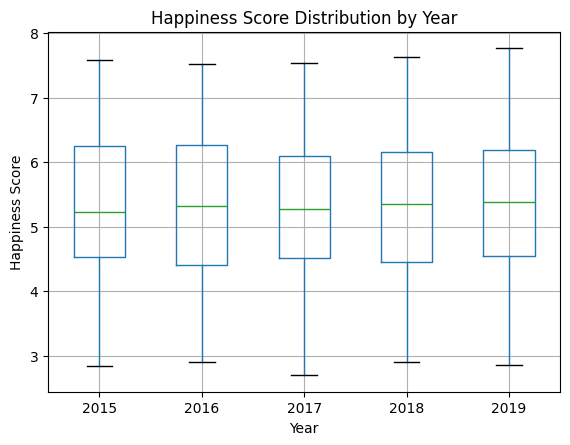

In [16]:
plt.figure(figsize=(8, 5))
df_model.boxplot(column="happiness_score", by="year")
plt.title("Happiness Score Distribution by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.show()

Se puede observar que la variable year no influye considerablemente en el happiness_score, en realidad se puede observar previamente que la correlacion es casi nula por ende se decide descartarla del modelo por el analisis realizado.

In [17]:
selected_features = [
    "gdp",
    "health",
    "social_support",
    "freedom",
    "corruption",
    "generosity"
]

target = "happiness_score"

X = df_model[selected_features]
y = df_model[target]

In [21]:
X = df_model[selected_features]
y = df_model[target]

print(X.head())
print("-----------------------------------------------------------------------------------")
print(y.head())

       gdp   health  social_support  freedom  corruption  generosity
0  1.39651  0.94143         1.34951  0.66557     0.41978     0.29678
1  1.30232  0.94784         1.40223  0.62877     0.14145     0.43630
2  1.32548  0.87464         1.36058  0.64938     0.48357     0.34139
3  1.45900  0.88521         1.33095  0.66973     0.36503     0.34699
4  1.32629  0.90563         1.32261  0.63297     0.32957     0.45811
-----------------------------------------------------------------------------------
0    7.587
1    7.561
2    7.527
3    7.522
4    7.427
Name: happiness_score, dtype: float64


STEP 4 - TRAIN REGRESSION MODEL
Model training, evaluation and serialization

In [24]:
from pathlib import Path
import joblib
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Divicion de los datos: 70 % para entrenamiento, 30 % para pruebas.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Creacion del modelo de regresion lineal (porque es un modelo sencillo)
model_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()), #normaliza las variables
    ("model", LinearRegression()) #entrena el modelo de regresión
])

# Entrenamiento del modelo (el modelo aprende la relación entre las variables predictoras y el happiness_score)
model_pipeline.fit(X_train, y_train)

# Predecir datos de prueba (el modelo predice el puntaje de felicidad)
y_pred = model_pipeline.predict(X_test)

# Evaluar modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("--------------------------------")
print("MAE:", round(mae, 4)) #Error promedio absoluto. Entre más bajo, mejor.
print("RMSE:", round(rmse, 4)) #Error promedio penalizando errores grandes. Entre más bajo, mejor.
print("R²:", round(r2, 4)) # Qué tanto explica el modelo. Más cercano a 1 es mejor.

# 6. Guardar modelo
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model_pipeline, MODELS_DIR / "model.pkl")

joblib.dump(list(X.columns), "models/features.pkl")

print("Features saved successfully in models/features.pkl")

print("Model saved successfully in models/model.pkl")

Model Evaluation Metrics
--------------------------------
MAE: 0.4321
RMSE: 0.5566
R²: 0.7519
Features saved successfully in models/features.pkl
Model saved successfully in models/model.pkl


Despues de realizar las metricas del modelo de regresion lineal realizado se puede ver que los valores dados dieron unos resultados buenos entre lo esperado, como el proposito del workshop no es obtener valores exactos en las predicciones se puede ver que estos resultados obtenidos son buenos para el modelo ya que son bajos y el del R² tiende a ser cercano a 1.